# 图表反演

In [3]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

/var/folders/54/bbrbnf8953d7z0fzwhskm0b00000gn/T/ipykernel_75643/349206853.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="category", y="percentage", data=gender_data, palette=["#ff6b6b", "#48dbfb"], ax=ax1)


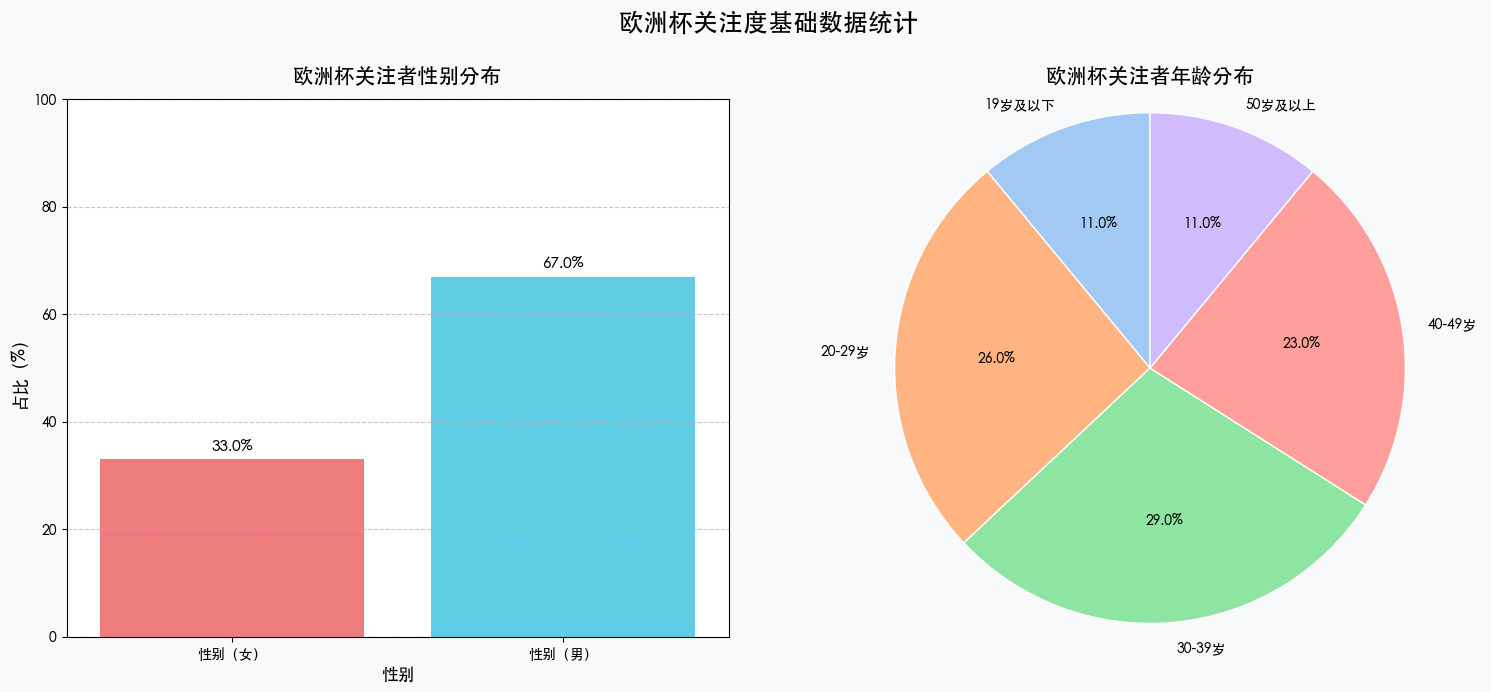

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 构建数据
data = {
    "category": ["性别（女）", "性别（男）", "19岁及以下", "20-29岁", "30-39岁", "40-49岁", "50岁及以上"],
    "percentage": [33, 67, 11, 26, 29, 23, 11]
}
df = pd.DataFrame(data)

# 分类数据为性别和年龄组
gender_data = df.iloc[:2]
age_data = df.iloc[2:]

# 创建一个包含两个子图的画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')  # 设置画布背景色

# 美化柱状图 - 性别分布
sns.barplot(x="category", y="percentage", data=gender_data, palette=["#ff6b6b", "#48dbfb"], ax=ax1)
ax1.set_title("欧洲杯关注者性别分布", fontsize=15, pad=12)
ax1.set_xlabel("性别", fontsize=12)
ax1.set_ylabel("占比（%）", fontsize=12)
ax1.set_ylim(0, 100)  # 设置y轴范围
ax1.grid(axis='y', linestyle='--', alpha=0.7)  # 优化网格线

# 添加性别分布数值标签
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width() / 2., height + 1.5,
             f'{height:.1f}%', ha="center", fontsize=11)

# 美化饼图 - 年龄分布
wedges, texts, autotexts = ax2.pie(
    age_data["percentage"],
    labels=age_data["category"],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    textprops={'fontsize': 10}
)
ax2.set_title("欧洲杯关注者年龄分布", fontsize=15, pad=12)
ax2.axis('equal')  # 保证饼图是正圆形

# 调整布局
plt.tight_layout(pad=3)  # 增加子图间距
plt.suptitle("欧洲杯关注度基础数据统计", fontsize=18, y=1.02, fontweight='bold')

# 显示图表
plt.show()    

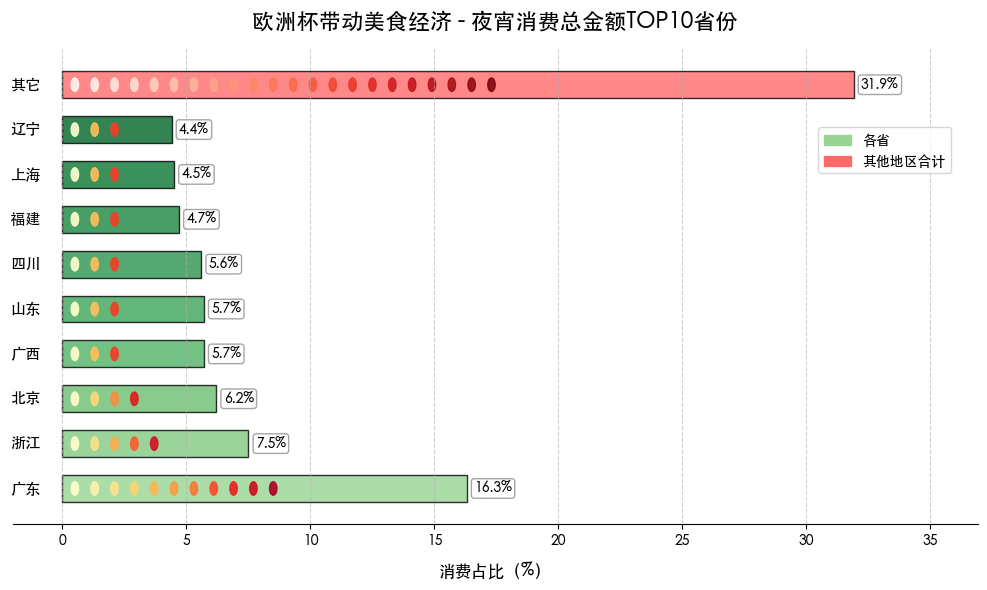

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# 构建数据
provinces = ["广东", "浙江", "北京", "广西", "山东", "四川", "福建", "上海", "辽宁", "其它"]
percentages = [16.3, 7.5, 6.2, 5.7, 5.7, 5.6, 4.7, 4.5, 4.4, 31.9]

# 创建画布和轴
fig, ax = plt.subplots(figsize=(10, 6))

# 设置渐变色（为"其它"使用不同颜色，其余省份使用渐变）
other_color = '#FF6B6B'  # 红色表示"其它"
province_colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(provinces) - 1))
colors = list(province_colors) + [other_color]  # 省份渐变在前，其它颜色在后

# 绘制水平条形图
bar_width = 0.6
y_pos = np.arange(len(provinces))
bars = ax.barh(y_pos, percentages, height=bar_width, color=colors, edgecolor='black', alpha=0.8)

# 自定义"烤串"样式
for i, (province, percent) in enumerate(zip(provinces, percentages)):
    # 计算珠子数量
    bead_count = max(1, int(percent * 0.7))  # 根据百分比确定珠子数量
    
    # 绘制珠子（圆形）
    for j in range(bead_count):
        bead_x = 0.5 + j * 0.8  # 珠子x位置
        if bead_x < percent - 0.5:  # 确保珠子不超出条形范围
            # "其它"项使用红色珠子，其余使用黄色渐变
            if i == len(provinces) - 1:
                bead_color = plt.cm.Reds(j/bead_count)
            else:
                bead_color = plt.cm.YlOrRd(j/bead_count)
            circle = mpatches.Circle(
                (bead_x, y_pos[i]), 
                radius=0.15, 
                color=bead_color,
                alpha=0.9
            )
            ax.add_patch(circle)
    
    # 添加省份标签（放在左侧）
    ax.text(-1.5, y_pos[i], province, ha='center', va='center', fontweight='bold', fontsize=11)

# 添加百分比数值标签（带背景框）
for i, rect in enumerate(bars):
    width = rect.get_width()
    ax.text(
        width + 0.3, rect.get_y() + rect.get_height()/2,
        f'{percentages[i]:.1f}%',  # 保留一位小数
        ha='left', va='center',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.2')
    )

# 设置坐标轴和标题
ax.set_xlim(-2, max(percentages) + 5)  # 调整x轴范围
ax.set_ylim(-0.8, len(provinces) - 0.2)  # 调整y轴范围
ax.set_title('欧洲杯带动美食经济 - 夜宵消费总金额TOP10省份', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('消费占比（%）', fontsize=12, labelpad=10)
ax.set_yticks([])  # 隐藏默认y轴标签

# 添加网格线
ax.grid(axis='x', linestyle='--', alpha=0.6)

# 添加图例并向下移动
province_patch = mpatches.Patch(color=province_colors[0], label='各省')
other_patch = mpatches.Patch(color=other_color, label='其他地区合计')
ax.legend(handles=[province_patch, other_patch], 
          loc='upper right', 
          bbox_to_anchor=(0.98, 0.85))  # 调整bbox_to_anchor参数向下移动

# 美化边框
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# 显示图表
plt.tight_layout()
plt.show()


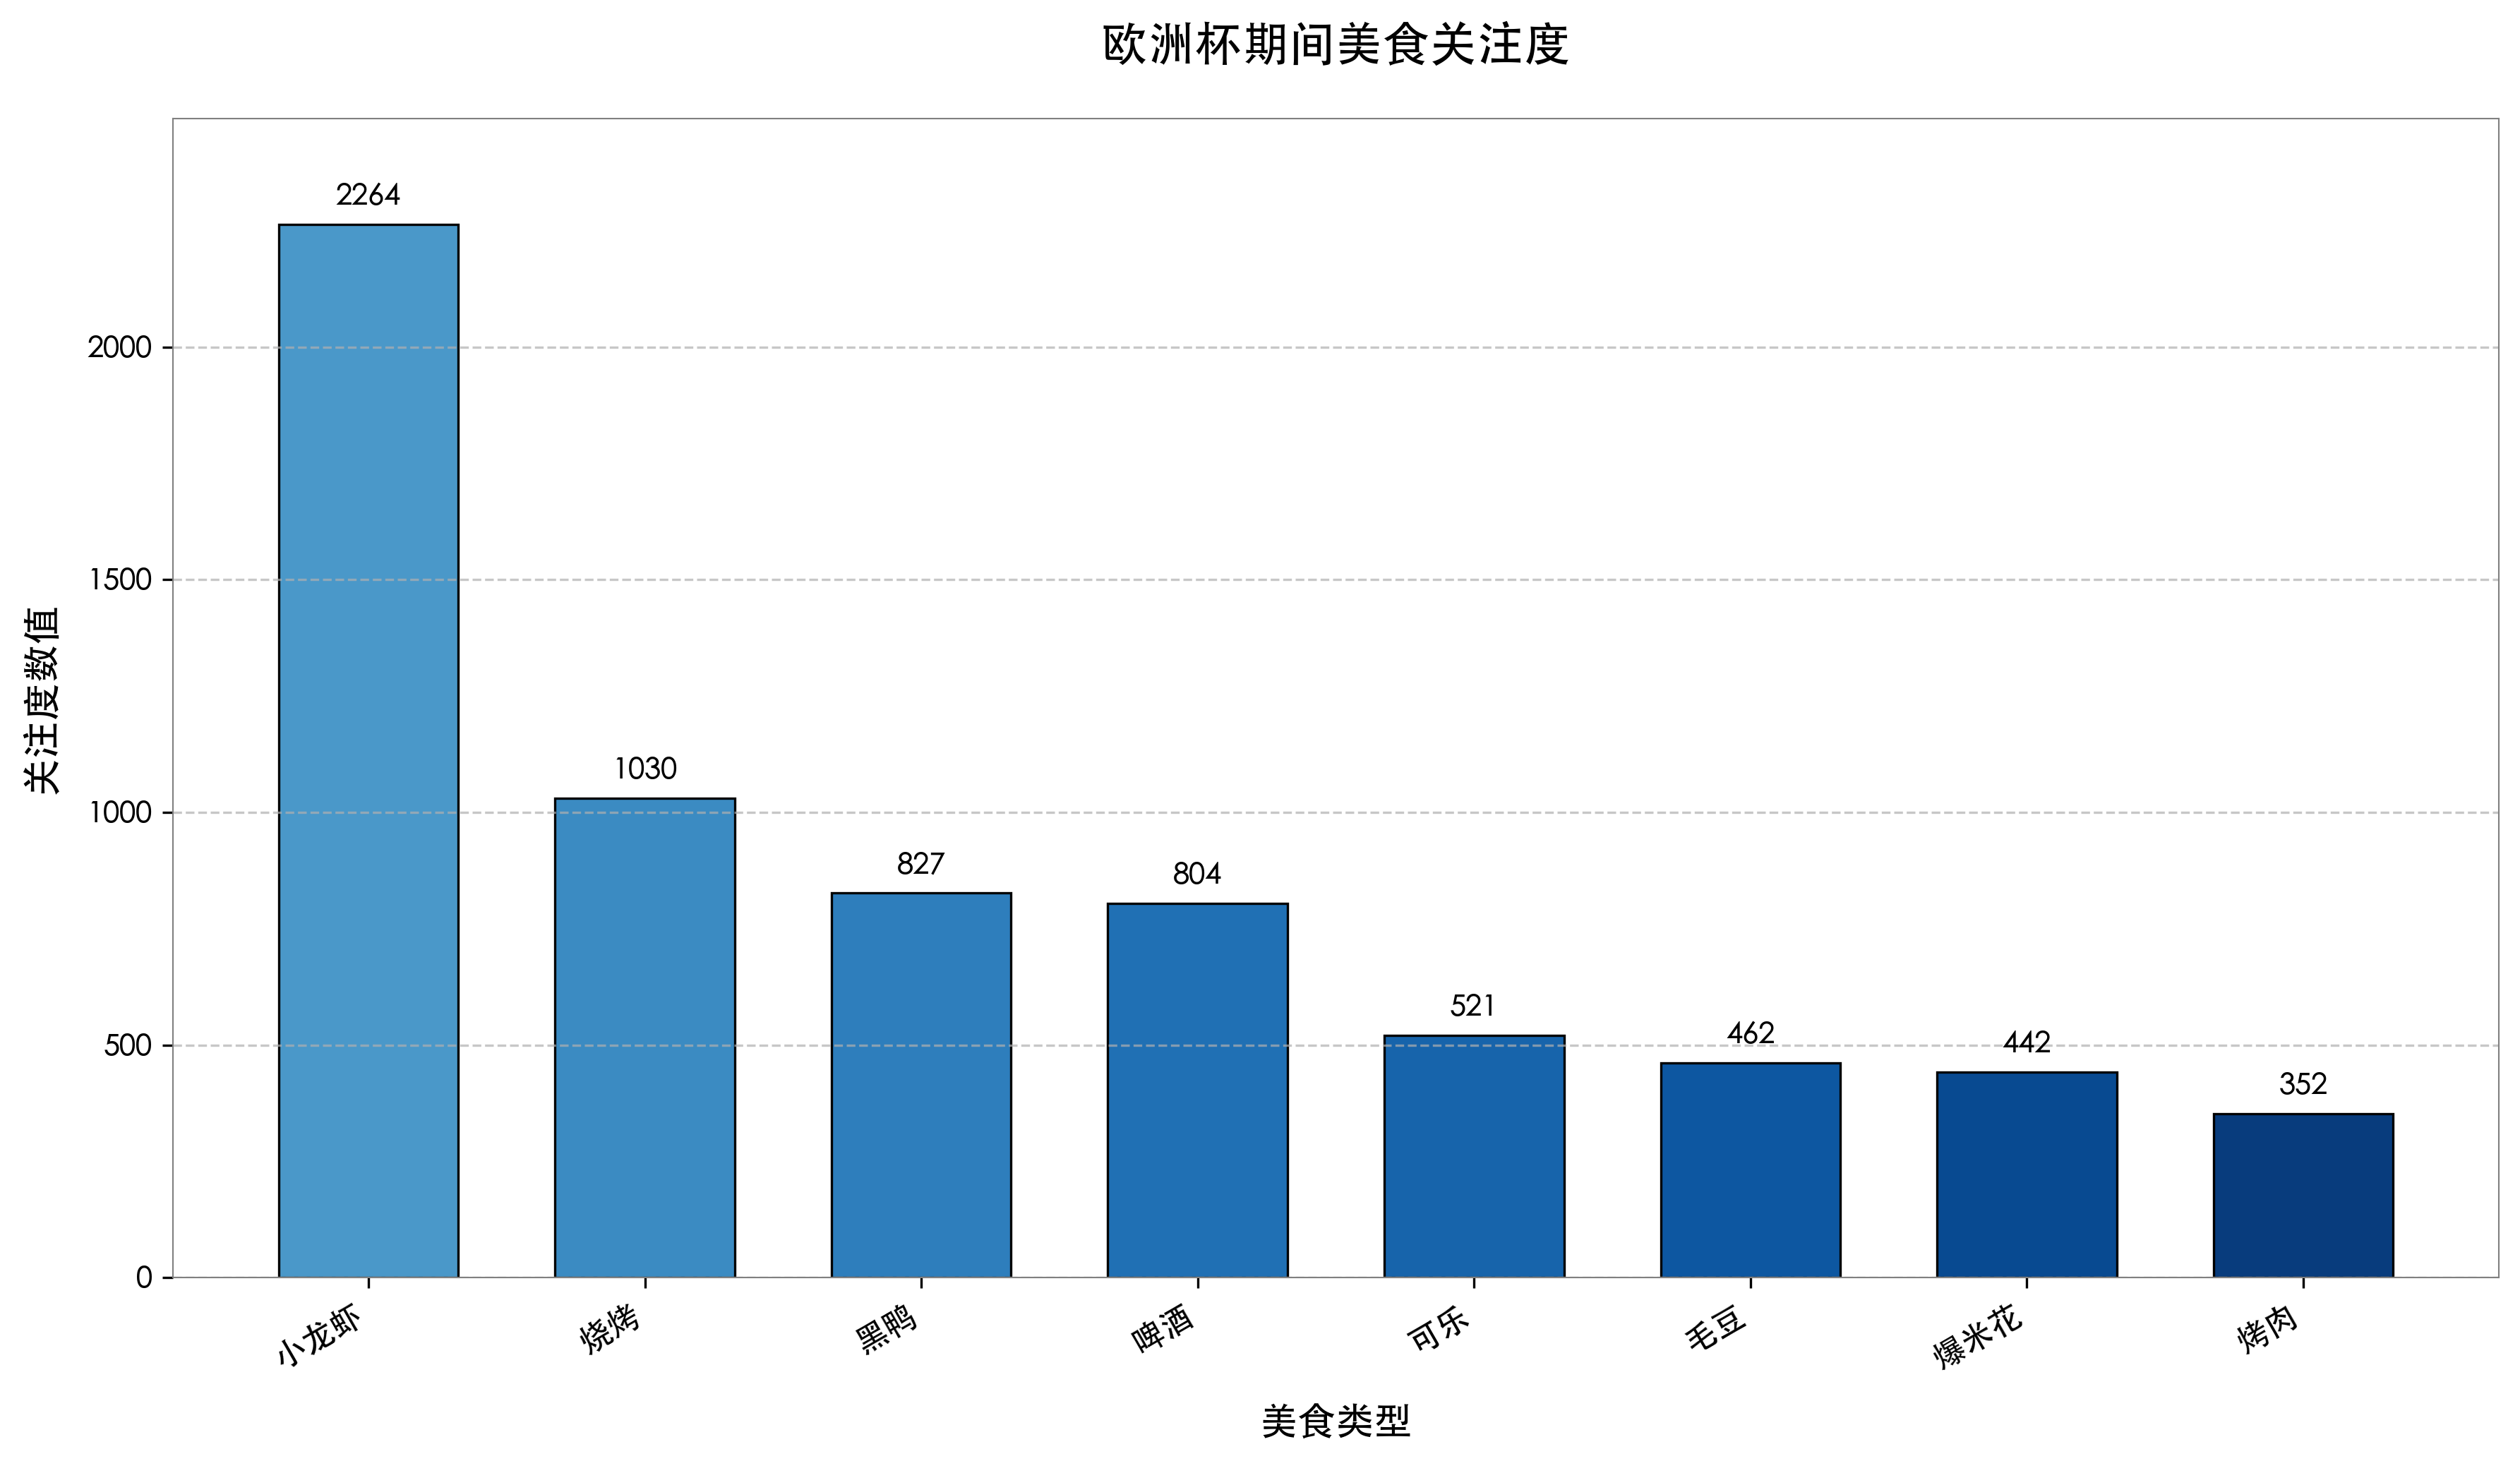

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
foods = ["小龙虾", "烧烤", "黑鸭", "啤酒", "可乐", "毛豆", "爆米花", "烤肉"]
values = [2264, 1030, 827, 804, 521, 462, 442, 352]

# 创建画布和子图（设置更大尺寸和分辨率）
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# 设置渐变色（从深蓝色到浅蓝色）
colors = plt.cm.Blues(np.linspace(0.6, 0.95, len(foods)))

# 绘制带圆角的柱状图（通过edgecolor和linewidth设置边框）
bars = ax.bar(
    x=np.arange(len(foods)),
    height=values,
    width=0.65,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    capstyle='round'
)

# 在柱状图上方添加数值标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + 30,  # 标签位置略高于柱子顶部
        f'{value}',
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# 设置x轴刻度标签（旋转45度增强可读性）
ax.set_xticks(np.arange(len(foods)))
ax.set_xticklabels(foods, rotation=30, ha='right', fontsize=11)

# 添加标题和坐标轴标签（增加字体大小和粗细）
ax.set_title('欧洲杯期间美食关注度', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('美食类型', fontsize=13, labelpad=10)
ax.set_ylabel('关注度数值', fontsize=13, labelpad=10)

# 设置y轴范围（留出顶部空间）
ax.set_ylim(0, max(values) * 1.1)

# 添加网格线增强可读性
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 美化图表边框
for spine in ax.spines.values():
    spine.set_color('gray')
    spine.set_linewidth(0.5)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()    

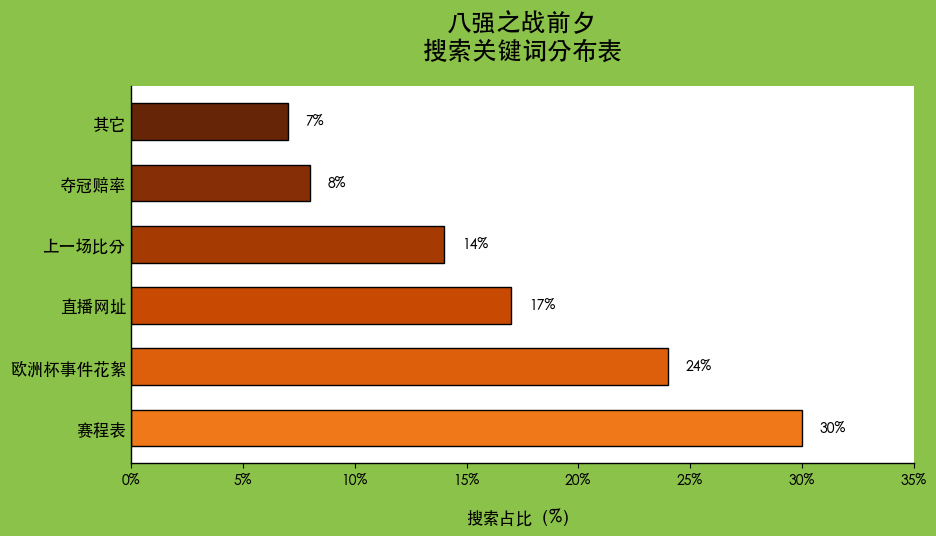

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
labels = ["赛程表", "欧洲杯事件花絮", "直播网址", "上一场比分", "夺冠赔率", "其它"]
percents = [30, 24, 17, 14, 8, 7]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#8BC34A')  # 绿色背景

# 绘制横向柱状图（使用黄色渐变）
y_pos = np.arange(len(labels))
colors = plt.cm.YlOrBr(np.linspace(0.6, 1, len(labels)))  # 黄色到橙色渐变
bars = ax.barh(y_pos, percents, color=colors, edgecolor='black', height=0.6)

# 添加标题和副标题
ax.set_title('八强之战前夕\n搜索关键词分布表', fontsize=18, fontweight='bold', pad=20)

# 设置y轴标签（关键词）
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.tick_params(axis='y', which='both', length=0)  # 隐藏y轴刻度线

# 设置x轴标签（百分比）
ax.set_xlabel('搜索占比（%）', fontsize=12, labelpad=15)
ax.set_xlim(0, 35)  # 留出右侧空间
ax.set_xticks(np.arange(0, 36, 5))
ax.set_xticklabels([f'{x}%' for x in np.arange(0, 36, 5)], fontsize=10)

# 为每个柱子添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.8, bar.get_y() + bar.get_height()/2,
            f'{width}%', ha='left', va='center', fontsize=10, fontweight='bold')

# 添加"人物图标"（使用matplotlib原生形状替代）
for i, (label, percent) in enumerate(zip(labels, percents)):
    # 绘制简化的"人物"（圆形头部+矩形身体）
    head = plt.Circle((-2.5, y_pos[i]), 0.3, color='yellow', ec='black')
    body = plt.Rectangle((-2.8, y_pos[i]-0.3), 0.6, 0.6, color='yellow', ec='black')
    ax.add_patch(head)
    ax.add_patch(body)
    
    # 添加"爱心"标记（使用三角形替代）
    heart_x = [-2.6, -2.4, -2.5]
    heart_y = [y_pos[i]+0.15, y_pos[i]+0.15, y_pos[i]+0.3]
    ax.fill(heart_x, heart_y, color='red')

# 添加"放大镜"标记（使用matplotlib原生形状）
for i, p in enumerate(percents):
    num_magnifiers = p // 5
    for j in range(num_magnifiers):
        # 绘制简化的放大镜
        magnifier_x = [-5 - j*0.8, -4.5 - j*0.8, -4.7 - j*0.8, -5 - j*0.8]
        magnifier_y = [y_pos[i]+0.1, y_pos[i]+0.1, y_pos[i]-0.1, y_pos[i]-0.1]
        ax.fill(magnifier_x, magnifier_y, color='black')
        # 放大镜手柄
        ax.plot([-4.5 - j*0.8, -4.3 - j*0.8], [y_pos[i], y_pos[i]-0.2], 'k-', linewidth=1.5)

# 隐藏顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# 调整布局
plt.tight_layout(pad=3)
plt.show()

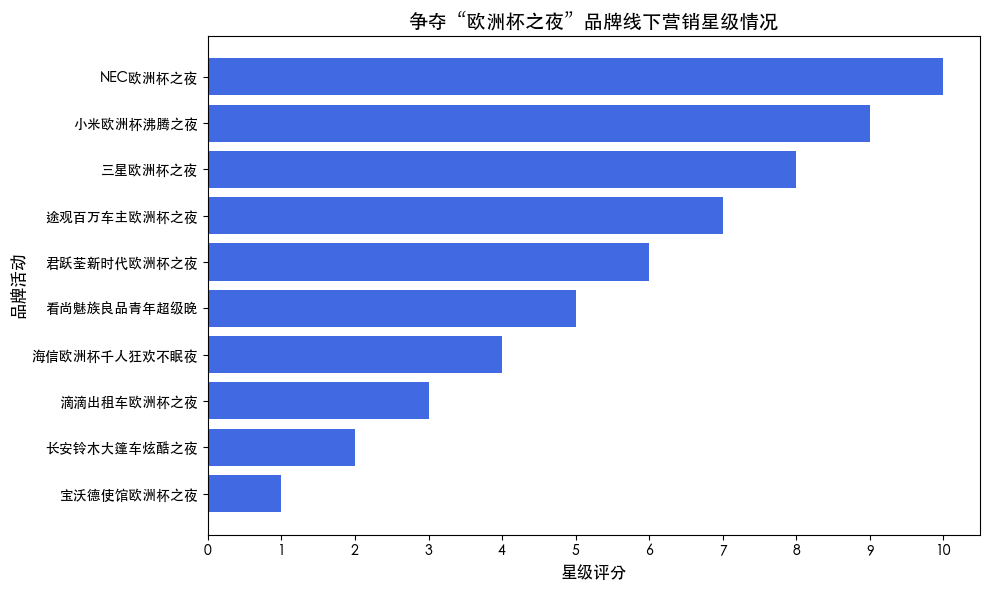

In [8]:
import matplotlib.pyplot as plt

# 数据
brands = [
    "NEC欧洲杯之夜",
    "小米欧洲杯沸腾之夜",
    "三星欧洲杯之夜",
    "途观百万车主欧洲杯之夜",
    "君跃荃新时代欧洲杯之夜",
    "看尚魅族良品青年超级晚",
    "海信欧洲杯千人狂欢不眠夜",
    "滴滴出租车欧洲杯之夜",
    "长安铃木大篷车炫酷之夜",
    "宝沃德使馆欧洲杯之夜"
]
ratings = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6))  # figsize可调整图表大小

# 绘制横向条形图
ax.barh(brands[::-1], ratings[::-1], color='royalblue')  

# 设置标题和坐标轴标签
ax.set_title('争夺“欧洲杯之夜”品牌线下营销星级情况', fontsize=14, fontweight='bold')
ax.set_xlabel('星级评分', fontsize=12)
ax.set_ylabel('品牌活动', fontsize=12)

# 设置x轴刻度（根据星级数量，这里0 - 10 ）
ax.set_xticks(range(0, 11))

# 显示图表
plt.tight_layout()  # 调整布局，避免标签重叠
plt.show()